In [4]:
import sys
from numpy import random as rd
from matplotlib.animation import FuncAnimation
import numpy as np
from matplotlib.animation import PillowWriter
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [5]:
def Random_walk(dimension,epochs,step_size = 1,starting_point = None):

    "This function generates a random walk in a given number of dimensions."
    "first give the dimension of the walk"
    "then give the number of epochs"
    "then give the step size"
    "then give the starting point"
    "the function will return a list of the positions of the walk"
    dimension_list=[]
    if starting_point is not None:
        if len(starting_point) == int(dimension):
            position = starting_point
        else:
            print("dimension of the starting point must be equal to dimension's of the walk :(")
            sys.exit()
    else:
        position = [0]*int(dimension)
    if type(step_size) != int:
        print("step size must be an integer :(")
        sys.exit()
    else:
        pass
        
    for dim in range(int(dimension)):
        dimension_list.append([])
        
    for epoch in range(epochs):
        direction = rd.randint(0,(int(dimension)))
        position[direction] = position[direction]+ rd.choice([-1*step_size,1*step_size])
        
        for dim in range(int(dimension)):
            dimension_list[dim].append(position[dim])
        
    return dimension_list

In [6]:
walker_1=Random_walk(2,10**5,1,[0,0])
walker_2=Random_walk(2,10**5,1,[10,10])

In [ ]:
from matplotlib.animation import PillowWriter


def animate_walkers(walkers_list, dimension=2, interval=25, save_gif=False, filename='animation.gif'):
    """
    Creates an animated visualization of multiple random walkers.
    
    Args:
        walkers_list: list of walker trajectories (each walker is output from Random_walk)
        dimension: 2 for 2D plot, 3 for 3D plot
        interval: delay between frames in milliseconds
        save_gif: whether to save animation as GIF
        filename: name of the GIF file
    """
    
    if dimension == 2:
        fig, ax = plt.subplots(figsize=(10, 10))
        
        def update(frame):
            ax.clear()
            for walker in walkers_list:
                ax.plot(walker[0][:frame], walker[1][:frame], alpha=0.6, linewidth=0.5)
                ax.scatter(walker[0][frame-1], walker[1][frame-1], s=20)
            ax.set_xlim(min([min(w[0]) for w in walkers_list])-5, max([max(w[0]) for w in walkers_list])+5)
            ax.set_ylim(min([min(w[1]) for w in walkers_list])-5, max([max(w[1]) for w in walkers_list])+5)
            ax.set_title(f'Random Walkers - Frame {frame}')
            
        max_steps = len(walkers_list[0][0])
        anim = FuncAnimation(fig, update, frames=range(1, max_steps, 100), interval=interval)
        
        if save_gif:
            anim.save(filename, writer=PillowWriter(fps=30))
            print(f"Animation saved as {filename}")
        
        plt.show()

In [ ]:
def animate_walkers(walkers_list, dimension=2, interval=25, save_gif=False, filename='animation.gif'):
    """
    Creates an animated visualization of multiple random walkers with visible trails.
    
    Args:
        walkers_list: list of walker trajectories (each walker is output from Random_walk)
        dimension: 2 for 2D plot, 3 for 3D plot
        interval: delay between frames in milliseconds
        save_gif: whether to save animation as GIF
        filename: name of the GIF file
    """
    
    if dimension == 2:
        fig, ax = plt.subplots(figsize=(10, 10))
        
        def update(frame):
            ax.clear()
            for walker in walkers_list:
                # Plot full trail with fade effect
                ax.plot(walker[0][:frame], walker[1][:frame], alpha=0.6, linewidth=1.5)
                # Highlight current position
                if frame > 0:
                    ax.scatter(walker[0][frame-1], walker[1][frame-1], s=50, zorder=5)
            ax.set_xlim(min([min(w[0]) for w in walkers_list])-5, max([max(w[0]) for w in walkers_list])+5)
            ax.set_ylim(min([min(w[1]) for w in walkers_list])-5, max([max(w[1]) for w in walkers_list])+5)
            ax.set_title(f'Random Walkers - Frame {frame}')
            
        max_steps = len(walkers_list[0][0])
        anim = FuncAnimation(fig, update, frames=range(1, max_steps, 100), interval=interval)
        
        if save_gif:
            anim.save(filename, writer=PillowWriter(fps=30))
            print(f"Animation saved as {filename}")
        
        plt.show()
        
    elif dimension == 3:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        def update(frame):
            ax.clear()
            for walker in walkers_list:
                # Plot full trail
                ax.plot(walker[0][:frame], walker[1][:frame], walker[2][:frame], alpha=0.6, linewidth=1.5)
                # Highlight current position
                if frame > 0:
                    ax.scatter(walker[0][frame-1], walker[1][frame-1], walker[2][frame-1], s=50, zorder=5)
            ax.set_title(f'Random Walkers 3D - Frame {frame}')
            
        max_steps = len(walkers_list[0][0])
        anim = FuncAnimation(fig, update, frames=range(1, max_steps, 100), interval=interval)
        
        if save_gif:
            anim.save(filename, writer=PillowWriter(fps=30))
            print(f"Animation saved as {filename}")
        
        plt.show()

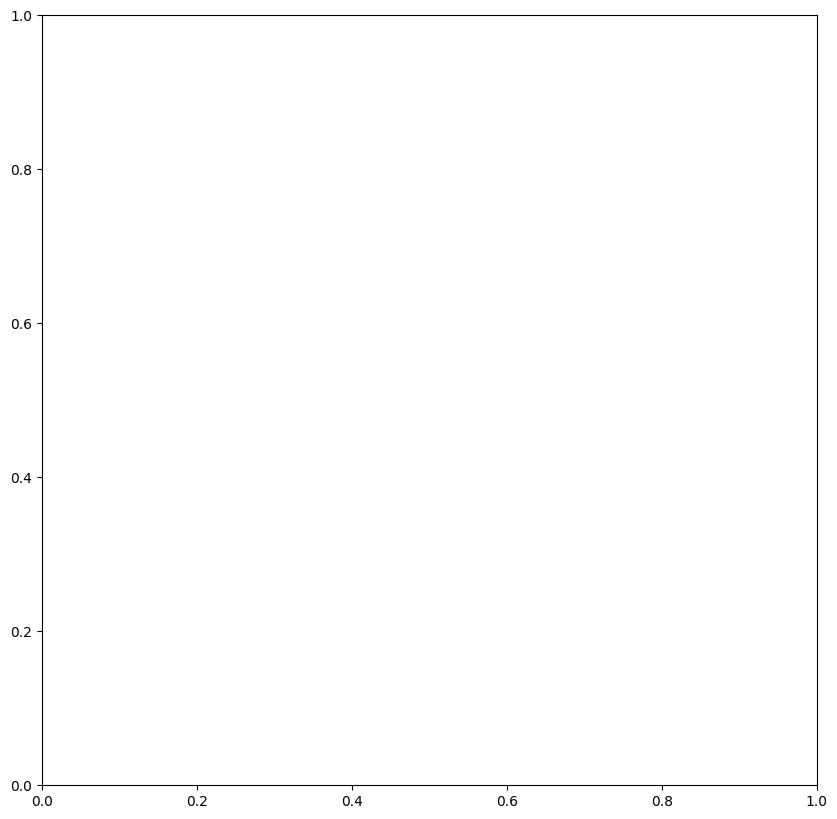

In [8]:
animate_walkers([walker_1, walker_2], dimension=2, interval=25)